# Phase 3, 4, 5 & 6: Outlier Treatment, Feature Selection, and Scaling
This notebook handles the visualization of extreme values, applies percentile capping (Winsorization), isolates the selected features, and applies standard scaling.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib
import os

sns.set_theme(style="whitegrid")

In [5]:
# Load the full dataset
file_path = '../data/raw/bank-full.csv'
df = pd.read_csv(file_path, sep=',')

target_features = ['age', 'balance', 'duration', 'campaign', 'previous']

## Phase 3: Outlier Analysis
Visualizing the extreme outliers in our target features before treatment.

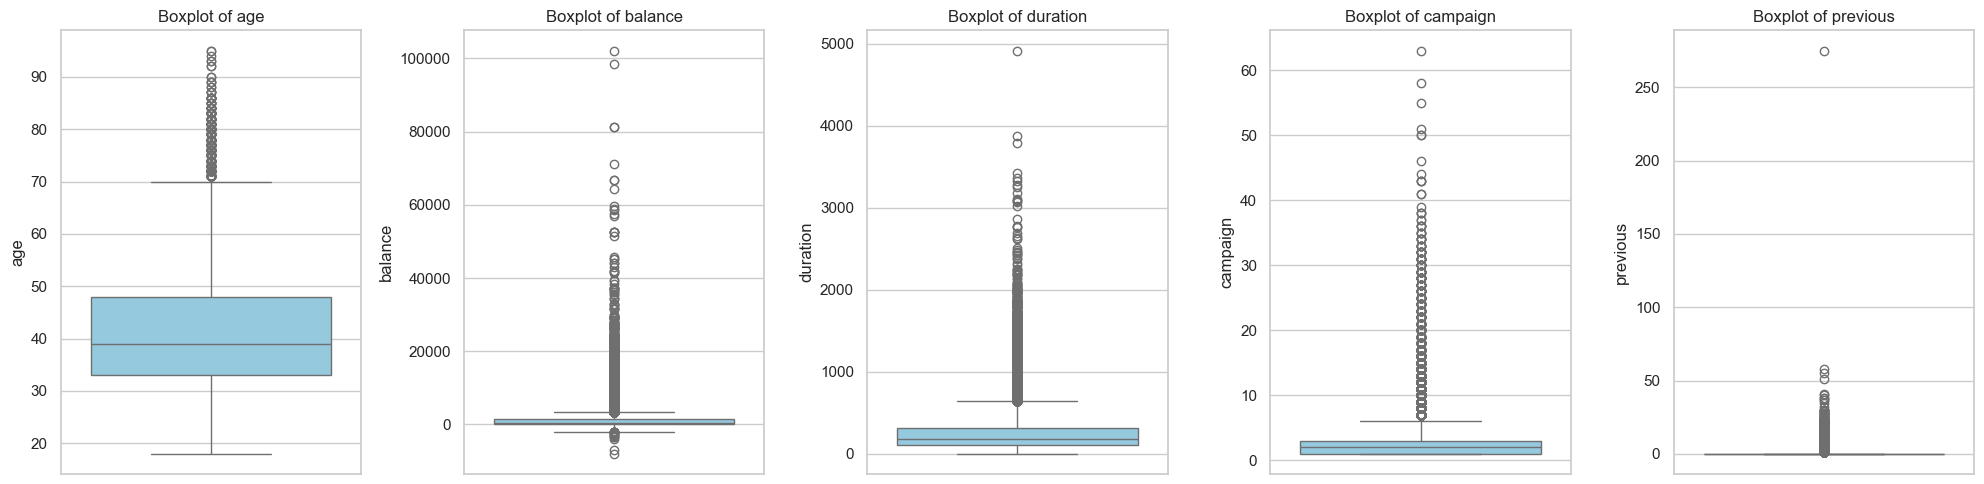

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(target_features):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

## Phase 4: Outlier Treatment (Winsorization)
We cap `balance` at the 1st and 99th percentiles, and `duration`, `campaign`, `previous` at the 99th percentile to protect K-Means centroids without deleting any records.

In [7]:
df_capped = df.copy()

# Calculate limits
limits = {
    'balance': (df['balance'].quantile(0.01), df['balance'].quantile(0.99)),
    'duration': (df['duration'].min(), df['duration'].quantile(0.99)),
    'campaign': (df['campaign'].min(), df['campaign'].quantile(0.99)),
    'previous': (df['previous'].min(), df['previous'].quantile(0.99))
}

# Apply caps using np.clip
for col, (lower, upper) in limits.items():
    df_capped[col] = np.clip(df_capped[col], lower, upper)
    print(f"{col} capped at: {lower:.2f} to {upper:.2f}")

# Compare max values before and after capping
print("\nMax values AFTER capping:")
print(df_capped[target_features].max())

balance capped at: -627.00 to 13164.90
duration capped at: 0.00 to 1269.00
campaign capped at: 1.00 to 16.00
previous capped at: 0.00 to 8.90

Max values AFTER capping:
age            95.0
balance     13164.9
duration     1269.0
campaign       16.0
previous        8.9
dtype: float64


## Phase 5: Feature Selection
Isolate only the 5 features required for clustering.

In [8]:
X = df_capped[target_features]
print(f"Feature Matrix Shape: {X.shape}")
display(X.head())

Feature Matrix Shape: (45211, 5)


,age,balance,duration,campaign,previous
0,58,2143.0,261,1,0.0
1,44,29.0,151,1,0.0
2,33,2.0,76,1,0.0
3,47,1506.0,92,1,0.0
4,33,1.0,198,1,0.0


## Phase 6: StandardScaler
Scale all features so they contribute equally to the Euclidean distance calculations in K-Means. Then save the fitted scaler to the models directory.

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for verification
df_scaled = pd.DataFrame(X_scaled, columns=target_features)
print("Scaled Data Statistics (Mean should be ~0, Std should be ~1):")
display(df_scaled.describe().round(3))

# Ensure models directory exists
os.makedirs('../models', exist_ok=True)

# Save the scaler
scaler_path = '../models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"\nSUCCESS: Scaler successfully saved to {scaler_path}")

Scaled Data Statistics (Mean should be ~0, Std should be ~1):


,age,balance,duration,campaign,previous
count,45211.000,45211.000,45211.000,45211.000,45211.000
mean,0.000,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-2.160,-0.847,-1.083,-0.654,-0.360
25%,-0.747,-0.536,-0.645,-0.654,-0.360
50%,-0.182,-0.369,-0.317,-0.267,-0.360
75%,0.665,0.067,0.275,0.119,-0.360
max,5.091,5.284,4.321,5.147,5.745



SUCCESS: Scaler successfully saved to ../models/scaler.pkl
